# Preprocessing (tabellare) – Iris + pipeline di pulizia



## Parte A — Iris (guidato)


## Import delle librerie

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

np.random.seed(42)

## Caricamento del dataset Iris

In [14]:
iris = load_iris(as_frame=True)
#stampiamo iris e vediamo quali sono le colonne e se vanno bene
#aggiungere stampa
iris.frame.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
df = iris.frame.copy()
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df = df.drop(columns=["target"])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Statistica descrittiva (come in Excel)

In [16]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#per vedere anche le statistiche sulle colonne categoriche, possiamo usare include='all'
#df.describe(include='all')

## Boxplot e IQR (outlier)

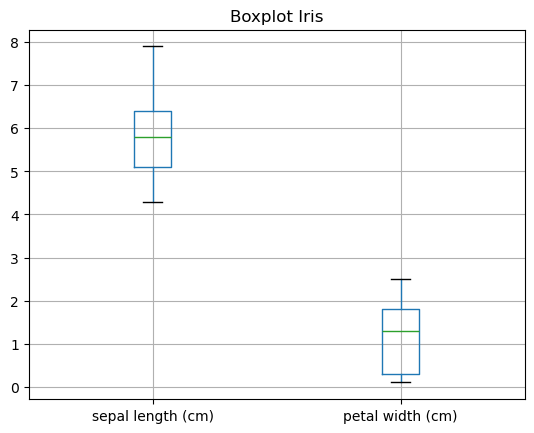

In [17]:
plt.figure()
df.boxplot(column=["sepal length (cm)", "petal width (cm)"])
plt.title("Boxplot Iris")
plt.show()

In [19]:
q1 = df["sepal length (cm)"].quantile(0.25)
q3 = df["sepal length (cm)"].quantile(0.75)
iqr = q3 - q1
iqr

1.3000000000000007

In [ ]:
#calcoliamo iqr anche per petal width, chiamandolo iqr_pw

##  Z-score (standardizzazione)

In [ ]:
z_scores = stats.zscore(df["sepal length (cm)"])
z_scores[:10]

#come sarebbe la formula se dovessimo calcolarlo manualmente?

0   -0.900681
1   -1.143017
2   -1.385353
3   -1.506521
4   -1.021849
5   -0.537178
6   -1.506521
7   -1.021849
8   -1.748856
9   -1.143017
Name: sepal length (cm), dtype: float64

##  Scatter plot e separabilità

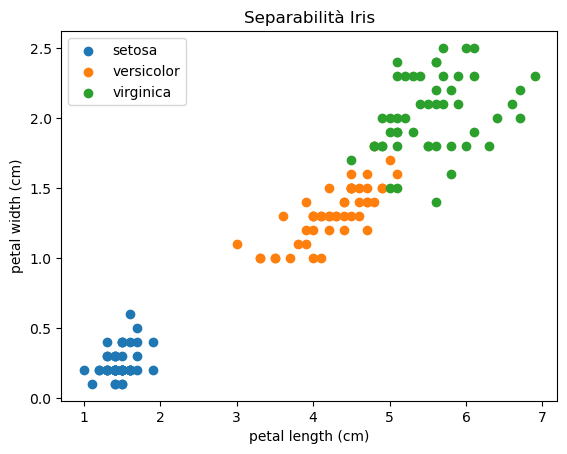

In [42]:
plt.figure()
for sp in df["species"].unique():
    sub = df[df["species"] == sp]
    plt.scatter(sub["petal length (cm)"], sub["petal width (cm)"], label=sp)

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()
plt.title("Separabilità Iris")
plt.show()

##  Split train/test (anticipazione ML)

In [ ]:
X = df.drop(columns=["species"])
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#Importanza di stratify?
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (120, 4)
Test shape: (30, 4)


8          setosa
106     virginica
76     versicolor
9          setosa
89     versicolor
Name: species, dtype: object

## Scaling con StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#Perchè abbiamo fit_transform su train e solo transform su test?
X_train_scaled[:5]

array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575]])

## Test t di Student (Welch)

Ipotesi nulla: le due specie hanno stessa media.

In [45]:

setosa = df[df["species"]=="setosa"]["petal length (cm)"]
versi = df[df["species"]=="versicolor"]["petal length (cm)"]

t_stat, p_val = stats.ttest_ind(setosa, versi, equal_var=False)
t_stat, p_val


(-39.492719391538095, 9.934432957587695e-46)

## Test Chi-quadro di indipendenza

Discretizziamo petal length in 3 livelli (basso/medio/alto)


In [46]:

df["pl_bin"] = pd.qcut(df["petal length (cm)"], q=3, labels=["Basso","Medio","Alto"])

cont = pd.crosstab(df["species"], df["pl_bin"])
cont


pl_bin,Basso,Medio,Alto
species,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,6,44


In [47]:
setosa = df[df["species"]=="setosa"]["petal length (cm)"]
versi = df[df["species"]=="versicolor"]["petal length (cm)"]

t_stat, p_val = stats.ttest_ind(setosa, versi, equal_var=False)
t_stat, p_val


(-39.492719391538095, 9.934432957587695e-46)

In [48]:
chi2, p_value, dof, expected = stats.chi2_contingency(cont)
chi2, p_value

(256.52173913043475, 2.561410449304364e-54)

In [49]:

pd.DataFrame(expected, index=cont.index, columns=cont.columns)

pl_bin,Basso,Medio,Alto
species,,,
setosa,16.666667,18.0,15.333333
versicolor,16.666667,18.0,15.333333
virginica,16.666667,18.0,15.333333



---

## Parte B — Preprocessing dati tabellari


## 1) Check rapido (info + describe)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    object  
 5   pl_bin             150 non-null    category
dtypes: category(1), float64(4), object(1)
memory usage: 6.3+ KB


In [29]:

df.columns = [c.replace(' (cm)', '').replace(' ', '_') for c in df.columns]
df.describe(include='all')

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 3) Simuliamo problemi reali: NaN + outlier artificiali

In [ ]:
df_dirty = df.copy()

rng = np.random.default_rng(42)
idx_nan = rng.choice(df_dirty.index, size=8, replace=False)
df_dirty.loc[idx_nan[:4], 'sepal_length (cm)'] = np.nan
df_dirty.loc[idx_nan[4:], 'petal width (cm)'] = np.nan

idx_out = rng.choice(df_dirty.index, size=3, replace=False)
df_dirty.loc[idx_out, 'petal length (cm)'] = df_dirty.loc[idx_out, 'petal length (cm)'] * 2.8

idx_nan, idx_out, df_dirty.loc[idx_out]

#perchè si rompe?
#una volta corretto, provate a vedere come variano le statistiche descrittive giocanndo con le size di nann e outlier

KeyError: 'petal length (cm)'

### 3.1) Missing per colonna

In [32]:
df_dirty.isna().sum()

sepal_length           0
sepal_width            0
petal_length           0
petal_width            0
species                0
sepal length (cm)    150
petal width (cm)     150
dtype: int64

## 4) Imputation con mediana

In [ ]:
df_imp = df_dirty.copy()

num_cols = ['sepal_length','sepal_width','petal_length','petal_width']
for c in num_cols:
    df_imp[c] = df_imp[c].fillna(df_imp[c].median())

#Perchè usiamo la mediana?

(df_dirty.isna().sum(), df_imp.isna().sum())

(sepal_length    4
 sepal_width     0
 petal_length    0
 petal_width     4
 species         0
 dtype: int64,
 sepal_length    0
 sepal_width     0
 petal_length    0
 petal_width     0
 species         0
 dtype: int64)

## 5) Outlier con regola IQR

In [ ]:
def iqr_bounds(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k*iqr
    hi = q3 + k*iqr
    return q1, q3, iqr, lo, hi

#cosa succede se modifichiamo k?

feat = 'petal_length'
q1, q3, iqr, lo, hi = iqr_bounds(df_imp[feat])
q1, q3, iqr, lo, hi

(1.6, 5.1, 3.4999999999999996, -3.649999999999999, 10.349999999999998)

In [42]:
mask_out = (df_imp[feat] < lo) | (df_imp[feat] > hi)
df_imp.loc[mask_out, [feat,'species']].head(20), mask_out.sum()

(     petal_length     species
 76          13.44  versicolor
 116         15.40   virginica,
 2)

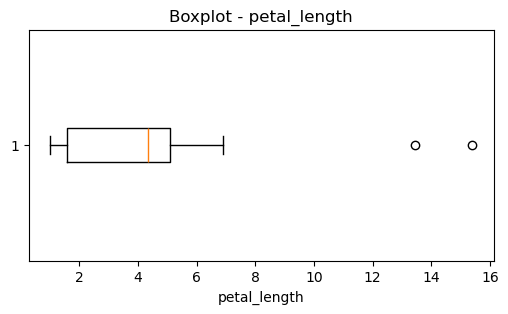

In [43]:
plt.figure(figsize=(6,3))
plt.boxplot(df_imp[feat].values, vert=False)
plt.title(f'Boxplot - {feat}')
plt.xlabel(feat)
plt.show()

### 5.1) Strategie: drop vs clip

In [44]:
df_drop = df_imp.loc[~mask_out].copy()
df_clip = df_imp.copy()
df_clip[feat] = df_clip[feat].clip(lower=lo, upper=hi)

len(df_imp), len(df_drop), df_imp[feat].max(), df_clip[feat].max()

(150, 148, 15.399999999999999, 10.349999999999998)

## 6) Scalatura: z-score e min-max

In [45]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df_clip[num_cols].copy()

sc_z = StandardScaler(); X_z = pd.DataFrame(sc_z.fit_transform(X), columns=[c+'_z' for c in num_cols])
sc_mm = MinMaxScaler(); X_mm = pd.DataFrame(sc_mm.fit_transform(X), columns=[c+'_mm' for c in num_cols])

pd.concat([X.head(), X_z.head(), X_mm.head()], axis=1).head()

,sepal_length,sepal_width,petal_length,petal_width,sepal_length_z,sepal_width_z,petal_length_z,petal_width_z,sepal_length_mm,sepal_width_mm,petal_length_mm,petal_width_mm
0,5.1,3.5,1.4,0.2,-0.893992,1.019004,-1.287533,-1.333071,0.222222,0.625000,0.042781,0.041667
1,4.9,3.0,1.4,0.2,-1.137145,-0.131979,-1.287533,-1.333071,0.166667,0.416667,0.042781,0.041667
2,4.7,3.2,1.3,0.2,-1.380298,0.328414,-1.340185,-1.333071,0.111111,0.500000,0.032086,0.041667
3,4.6,3.1,1.5,0.2,-1.501875,0.098217,-1.234880,-1.333071,0.083333,0.458333,0.053476,0.041667
4,5.0,3.6,1.4,0.2,-1.015569,1.249201,-1.287533,-1.333071,0.194444,0.666667,0.042781,0.041667


## 7) Trasformazioni sulla struttura (rename/drop/merge/pivot/agg)

In [46]:
df_struct = df_clip
small = df_struct[['sepal_length','sepal_width','species']].copy()
small.head()

,sepal_length,sepal_width,species
0,5.1,3.5,setosa
1,4.9,3.0,setosa
2,4.7,3.2,setosa
3,4.6,3.1,setosa
4,5.0,3.6,setosa


In [47]:
species_info = pd.DataFrame({
    'species':['setosa','versicolor','virginica'],
    'group':['A','B','C'],
    'note':['petali piccoli','intermedio','petali grandi']
})
merged = small.merge(species_info, on='species', how='left')
merged.head()

,sepal_length,sepal_width,species,group,note
0,5.1,3.5,setosa,A,petali piccoli
1,4.9,3.0,setosa,A,petali piccoli
2,4.7,3.2,setosa,A,petali piccoli
3,4.6,3.1,setosa,A,petali piccoli
4,5.0,3.6,setosa,A,petali piccoli


In [48]:
long = df_struct.melt(id_vars=['species'], value_vars=['sepal_length','sepal_width','petal_length','petal_width'],
                      var_name='feature', value_name='value')
long.head()

,species,feature,value
0,setosa,sepal_length,5.1
1,setosa,sepal_length,4.9
2,setosa,sepal_length,4.7
3,setosa,sepal_length,4.6
4,setosa,sepal_length,5.0


In [49]:
agg = df_struct.groupby('species')[['sepal_length','sepal_width','petal_length','petal_width']].agg(['mean','std','count'])
agg

sepal_length                 sepal_width                  \
                   mean       std count        mean       std count   
species                                                               
setosa            5.006  0.352490    50       3.428  0.379064    50   
versicolor        5.940  0.514286    50       2.770  0.313798    50   
virginica         6.560  0.658384    50       2.974  0.322497    50   

           petal_length                 petal_width                  
                   mean       std count        mean       std count  
species                                                              
setosa            1.516  0.424437    50       0.270  0.180984    50  
versicolor        4.371  0.979384    50       1.324  0.197495    50  
virginica         5.649  0.874496    50       2.014  0.292777    50

## 8) One-hot encoding (categoriche → numeriche)

In [50]:
one_hot = pd.get_dummies(df_struct['species'], prefix='species')
X_final = pd.concat([df_struct.drop(columns=['species']), one_hot], axis=1)
X_final.head()

,sepal_length,sepal_width,petal_length,petal_width,species_setosa,species_versicolor,species_virginica
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False


## 9) Output pronto per ML
A questo punto i dati sono puliti, scalati e in formato numerico: pronti per essere dati in pasto a un modello.